In [1]:
from walsh_pauli_decomposition import decompose_interaction_term, decompose_potential_term, decompose_laplacian_term
from circuit_constructor import create_pauli_rotation_circuit, create_fourier_basis_rotation_circuit
import numpy as np
from qiskit import QuantumCircuit


In [2]:
V0 = 100
kappa = 1

In [3]:
N = 2
X = np.linspace(0,1,2**N,endpoint=False)
psi = np.exp(-((X - 0.5)**2) / (2 * 0.1**2))
psi = psi / np.linalg.norm(psi)  
psi = np.kron(psi,psi)
T_final = 0.2
dt = 0.0002
Nt = int(T_final/dt)
interpolate = True


In [4]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.quantum_info import Statevector  
from walsh_trotterization import create_trotter_step_circuit
from circuit_constructor import create_pauli_rotation_circuit, create_fourier_basis_rotation_circuit
from walsh_pauli_decomposition import decompose_potential_term, decompose_laplacian_term

potential_decomp = decompose_potential_term(N, V0, interpolate=interpolate)
potential_circuit_half =  create_pauli_rotation_circuit(N, dt/2, potential_decomp)

kinetic_decomp = decompose_laplacian_term(N, interpolate=interpolate)
kinetic_circuit = create_fourier_basis_rotation_circuit(N, dt, kinetic_decomp)

interaction_decomp = decompose_interaction_term(N,kappa=kappa)
interaction_circuit = create_pauli_rotation_circuit(2*N,dt/2,interaction_decomp)

simulator = AerSimulator(method='statevector')
state = Statevector(psi)

from qiskit.circuit.library import MCPhaseGate, PhaseGate
from qiskit.quantum_info import Statevector, Operator


In [42]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import MCPhaseGate,PhaseGate

def construct_MCP_interaction_circuit(N,dt,kappa):
    qc = QuantumCircuit(2*N)
    if N>1:
        mcp = MCPhaseGate(-kappa*dt/2*2**N,N-1,ctrl_state=0)
    else:
        mcp = PhaseGate(-kappa*dt/2*2**N)
    for i in range(N):
        qc.cx(i,i+N)
    qc.x(2*N-1)
    qc.append(mcp, range(N,2*N))
    qc.x(2*N-1)
    for i in range(N):
        qc.cx(i,i+N)
    return qc

In [38]:

def create_trotter_step_circuit(N, dt, V0=1.0,kappa=1, interpolate=False, MCP_interaction=False):
 
    qc = QuantumCircuit(2*N)
    
    # Second-order Trotter: exp(-i V dt/2) exp(-i K dt) exp(-i V dt/2)
    
    if V0 != 0:
        potential_decomp = decompose_potential_term(N, V0, interpolate=interpolate)
        potential_circuit_half =  create_pauli_rotation_circuit(N, dt/2, potential_decomp)
    # Interaction term
    if MCP_interaction:
        interaction_circuit = construct_MCP_interaction_circuit(N,dt/2,kappa)
    else:    
        interaction_decomp = decompose_interaction_term(N,kappa=kappa)
        interaction_circuit = create_pauli_rotation_circuit(2*N,dt/2,interaction_decomp)

    ##kinetic_circuit = create_kinetic_wp_circuit(N, dt, walsh_factor, power_factor)
    kinetic_decomp = decompose_laplacian_term(N, interpolate=interpolate)
    kinetic_circuit = create_fourier_basis_rotation_circuit(N, dt, kinetic_decomp)
    

    # Trotter step
    # First half of potential evolution
    if V0 != 0:
        qc.compose(potential_circuit_half,range(N), inplace=True)
        qc.compose(potential_circuit_half,range(N,2*N), inplace=True)
        qc.compose(interaction_circuit,inplace=True)
    # kinetic evolution
    qc.compose(kinetic_circuit, range(N), inplace=True)
    qc.compose(kinetic_circuit, range(N,2*N), inplace=True)

    # Second half of potential evolution: exp(-i V_WP dt/2)
    if V0 != 0:
        qc.compose(potential_circuit_half,range(N), inplace=True)
        qc.compose(potential_circuit_half,range(N,2*N), inplace=True)
        qc.compose(interaction_circuit,inplace=True)
    
    return qc

In [39]:
trotter_circuit_2reg = create_trotter_step_circuit(N,dt,V0,interpolate=True)

## Let us look at the scaling for a basic compilation of the MCP and interaction rotation gate

In [43]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import copy 
lens = {}
for N in  range(1,10):
#N = 3
    interaction_decomp = decompose_interaction_term(N,kappa=kappa)
    decomp = copy.copy(interaction_decomp)
    decomp.pop("I"*2*N)
    keys = list(decomp.keys())
    values = list(decomp.values())
    operator = SparsePauliOp(keys,values)

    evo_gate = PauliEvolutionGate(operator, time=dt)

    qc = QuantumCircuit(2*N)
    qc.append(evo_gate, range(2*N))
    pm = generate_preset_pass_manager(optimization_level=3, backend=None)
    optimized_qc = pm.run(qc)
    qc_mcp = construct_MCP_interaction_circuit(N,dt,1)
    basis_gates = ['cx', 'u'] 
    transpiled_qc_mcp = transpile(qc, basis_gates=basis_gates, optimization_level=3)
    lens[N]= [len(transpiled_qc_mcp),len(optimized_qc)]

/Users/fserret/.pyenv/versions/torch_env/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/fserret/.pyenv/versions/torch_env/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [45]:
import matplotlib.pyplot as plt

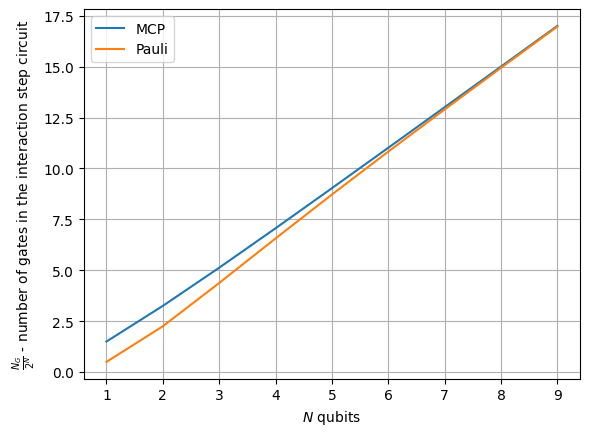

In [49]:
plt.plot(lens.keys(),np.asarray(list(lens.values()))[:,0]/2**np.asarray(list(lens.keys())),label='MCP')
plt.plot(lens.keys(),np.asarray(list(lens.values()))[:,1]/2**np.asarray(list(lens.keys())),label='Pauli')
plt.legend()
plt.ylabel(r"$\frac{N_{G}}{2^N}$ - number of gates in the interaction step circuit")
plt.xlabel(r"$N$ qubits")
plt.grid()

## Note that there exists a linear circuit with N-2 ancilla qubits for MCP

## Now we test the equivalence of the two circuits(up to a global phase)

In [ ]:
from qiskit.circuit.library import MCPhaseGate,PhaseGate
from qiskit.quantum_info import Statevector, Operator
from utils import remove_global_phase

N=10

if N>1:
    mcp = MCPhaseGate(-kappa*dt/2*2**N,N-1,ctrl_state=0)
else:
    mcp = PhaseGate(-kappa*dt/2*2**N)
qc = QuantumCircuit(2*N)
for i in range(N):
    qc.cx(i,i+N)
qc.x(2*N-1)
qc.append(mcp, range(N,2*N))
qc.x(2*N-1)
for i in range(N):
    qc.cx(i,i+N)

In [87]:
state.evolve(qc).data/state.data

interaction_decomp = decompose_interaction_term(N,kappa=kappa)
interaction_circuit = create_pauli_rotation_circuit(2*N,dt/2,interaction_decomp)


In [88]:
np.linalg.norm(np.angle(remove_global_phase(np.diag(Operator(qc))))-np.angle(remove_global_phase(np.diag(Operator(interaction_circuit)))))

np.float64(8.505245875511622e-21)

In [89]:
np.angle(remove_global_phase(np.diag(Operator(interaction_circuit))))

array([-1.87416736e-21,  2.00000000e-04,  2.00000000e-04, -1.87416736e-21])